<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/AML_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
X= np.array([1,2,3,4,5]).reshape(-1,1)
X
#Input study hours
#know about -1,1 in reshape

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [ ]:
#output marks
y =np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [ ]:
#create and train the model
model=LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
#display the regression parameters
print("Intercept :",model.intercept_)
print("Coefficient :",model.coef_)
print("Slope:",model.coef_[0])


Intercept : 33.0
Coefficient : [7.]
Slope: 7.0


In [ ]:
#Predict marks for siz study hours
new_data=np.array([[6]])
predicted_mark=model.predict(new_data)
print("Predicted marks for 6 hours study:",predicted_mark[0])

Predicted marks for 6 hours study: 75.0


In [ ]:
#Preditiontion for the original observation
y_pred=model.predict(X)
y_pred

array([40., 47., 54., 61., 68.])

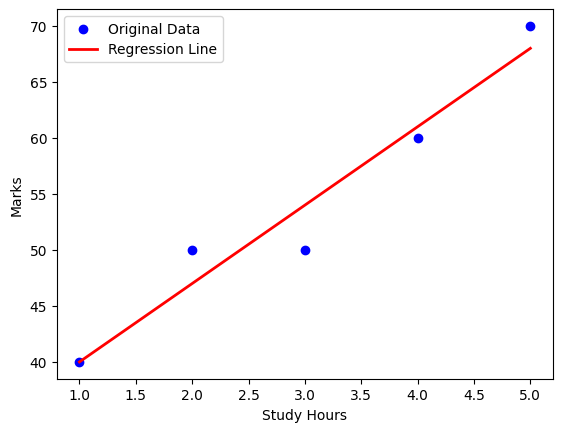

In [ ]:
#plot data and regression line
plt.scatter(X,y,color="blue",label="Original Data")
plt.plot(X,y_pred,color="red",linewidth=2,label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (mean_absolute_error,root_mean_squared_log_error,mean_squared_error,r2_score)

In [ ]:
mae=mean_absolute_error(y,y_pred)
mse=mean_squared_error(y,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y,y_pred)

In [ ]:
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("ROot mean squared :", rmse)
print("R-squared:",r2)

Mean Absolute Error: 2.0
Mean Squared Error: 6.0
ROot mean squared : 2.449489742783178
R-squared: 0.9423076923076923


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
data={
    "Study_hours:": [1,2,3,4,5,6,7,8,9,10],
    "Marks":[32,38,43,50,54,61,68,73,81,88]
}

In [ ]:
df=pd.DataFrame(data)
df

,Study_hours:,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [ ]:
x=df[["Study_hours:"]]
y=df["Marks"]

In [ ]:
x

,Study_hours:
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([80.19827586, 37.05172414])

In [ ]:
print("Intercept ",model.intercept_)
print("Coefficient ",model.coef_)
print("Slope ",model.coef_[0])
print("actual values", y_test.values)
print("predicted values",y_pred)

Intercept  24.724137931034484
Coefficient  [6.1637931]
Slope  6.163793103448276
actual values [81 38]
predicted values [80.19827586 37.05172414]


In [ ]:
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R-squared",r2_score(y_test,y_pred))

MAE:  0.875
MSE 0.7709943519619504
RMSE 0.8780628405541089
R-squared 0.9983320836085193


Multiple linear regression


In [ ]:
import pandas as pd
data ={
    "Study_hours":[2,3,4,5,6,7,8,9],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Assignment_score":[50,55,58,65,70,74,80,88],
    "Final_Marks":[42,48,54,61,67,73,81,89]
}
#add study hours per week ,
#convert this to csv then use csv to process the data


In [ ]:
df=pd.DataFrame(data)
X=df[["Study_hours","Attendance","Assignment_score"]]
y=df["Final_Marks"]

In [ ]:
model=LinearRegression()
model.fit(X,y)
print("Intercept ",model.intercept_)
print("Coefficient ",model.coef_)
print("Slope ",model.coef_)

Intercept  -28.31652806652808
Coefficient  [0.13141026 0.65705128 0.60810811]
Slope  [0.13141026 0.65705128 0.60810811]


In [ ]:
cofficient_table=pd.DataFrame({
    "Features":X.columns,
    "Coefficient":model.coef_
})
cofficient_table

,Features,Coefficient
0,Study_hours,0.131410
1,Attendance,0.657051
2,Assignment_score,0.608108


In [ ]:
new_student=pd.DataFrame({
    "Study_hours":[6],
    "Attendance":[82],
    "Assignment_score":[72]
})

In [ ]:
y_predition=model.predict(new_student)
print("Predicted final Marks  ",y_predition[0])

Predicted final Marks   70.13392238392238


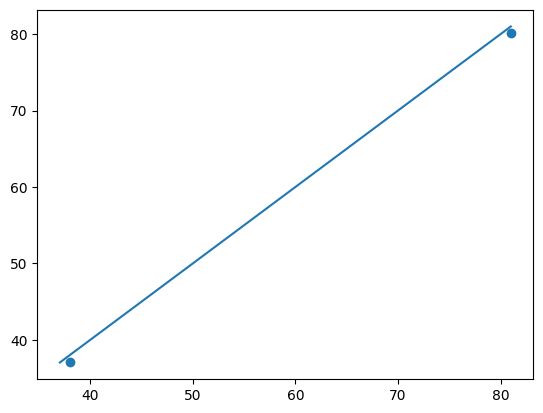

In [ ]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
minimum=min(y_test.min(),y_pred.min())
maximum=max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],[minimum,maximum])
plt.scatter(y_test,y_pred)

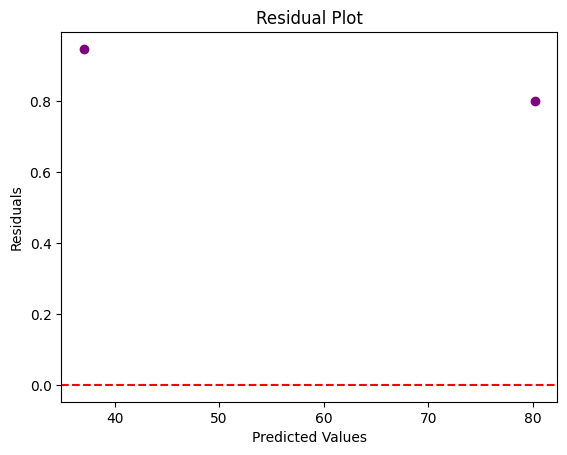

In [ ]:
#this shows that the given problelm is linear regression or its polynomial regression
from matplotlib import lines
residual =y_test - y_pred
plt.scatter(y_pred,residual,color='purple')
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
data={
    "Size":[800,1000,1200,1500,1800],
    "Location":["Rural","Urban","Rural","Urban","Urban"],
    "Price":[30,50,42,72,85]
}

df=pd.DataFrame(data)
df

,Size,Location,Price
0,800,Rural,30
1,1000,Urban,50
2,1200,Rural,42
3,1500,Urban,72
4,1800,Urban,85


In [ ]:
df_encoded=pd.get_dummies(
    df,
    columns=["Location"],
    drop_first=True,
    dtype=int
)
df_encoded

,Size,Price,Location_Urban
0,800,30,0
1,1000,50,1
2,1200,42,0
3,1500,72,1
4,1800,85,1


In [ ]:
# task 3 : check if the dataset has multiple linearrty or not for 2 datasets